In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import pickle
import matplotlib.pyplot as plt

with open("../data/RML2016.10a_dict.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

print(type(data))

C:\Users\lnloh\AppData\Local\Temp\ipykernel_6772\1512028997.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")


<class 'dict'>


In [2]:
keys = list(data.keys())

mods = sorted(set(mod for mod, snr in keys))
snrs = sorted(set(snr for mod, snr in keys))

print(f"Total keys: {len(keys)}")
print(f"Modulations: {mods}")
print(f"SNRs: {snrs}")

Total keys: 220
Modulations: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNRs: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [ ]:
sample_key = ("BPSK", 18)
array = data[sample_key]
print(f"Shape of the array for key {sample_key}: {array.shape}")
print(f"Single sample shape: {array[0].shape}")
print(f"Data type of the array: {array.dtype}")

Shape of the array for key ('BPSK', 18): (1000, 2, 128)
Single sample shape: (2, 128)
Data type of the array: float32


In [ ]:
sample = data[("BPSK", 18)][0]

print(f"I channel (first 10 values ):\n{sample[0][:10]}")
print(f"Q channel (first 10 values ):\n{sample[1][:10]}")

print(f"\n I min: {sample[0].min():.4f}, I max: {sample[0].max():.4f}")
print(f" Q min: {sample[1].min():.4f}, Q max: {sample[1].max():.4f}")

I channel (first 10 values ):
[-3.1633020e-04  6.6836037e-05 -7.6790003e-04 -5.7558407e-04
 -5.5835804e-04  1.4250478e-04  2.3223397e-04  4.7186663e-04
 -2.0780989e-04  5.0438923e-04]
Q channel (first 10 values ):
[ 0.00014015 -0.00019198 -0.00037653 -0.00032971 -0.0004105   0.00055068
  0.00106949 -0.00040754  0.00066566  0.00014849]

 I min: -0.0177, I max: 0.0129
 Q min: -0.0631, Q max: 0.0705


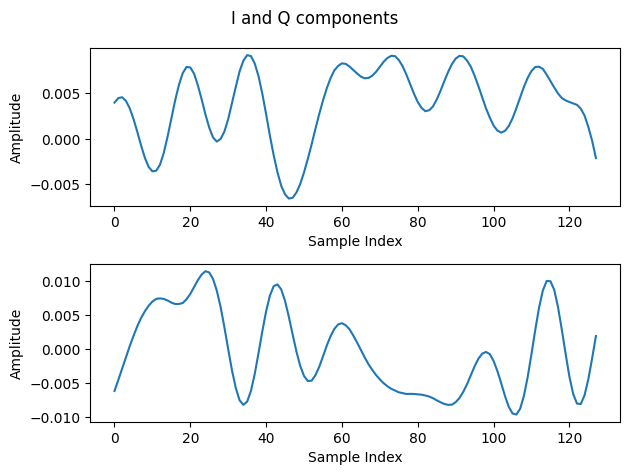

In [11]:
sample_key = ("QAM16", 18)
test = data[sample_key][0]


def plot_iq(sample):
    i_row = sample[0, :]
    q_row = sample[1, :]
    x = range(len(i_row))
    fig, axs = plt.subplots(2)
    plt.suptitle("I and Q components")
    axs[0].plot(x, i_row)
    axs[0].set_xlabel("Sample Index")
    axs[0].set_ylabel("Amplitude")
    axs[1].plot(x, q_row)
    axs[1].set_xlabel("Sample Index")
    axs[1].set_ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


plot_iq(test)